# ACTUWISE - Module 2 : Provisionnement des Reserves Techniques
## Partie 1 - Methodes Actuarielles Classiques

---

**Auteur :** [Prenom Nom] - Stage Actuariat  
**Module :** Module 2 - Provisionnement  
**Partie :** 1 - Methodes actuarielles classiques (sans Machine Learning)  
**Donnees :** SAP_AUTO_PAR_GARANTIES_AU_31122023_MAJ.xls + Base_production_sur_6_ans.xlsx

---

### Objectifs de ce notebook

1. **Methode Chain-Ladder** - projection deterministe des triangles de developpement (Mack, 1993)
2. **Methode Bornhuetter-Ferguson (BF)** - estimation hybride a priori + donnees observees (BF, 1972)
3. **Methode Cape Cod (CC)** - estimation par taux de sinistralite global (Stanard, 1985)
4. **Comparaison** des trois methodes et recommandation motivee
5. **Stress tests** de robustesse des reserves

### References academiques

- Mack, T. (1993). Distribution-Free Calculation of the Standard Error of Chain Ladder Reserve Estimates. ASTIN Bulletin, 23(2), 213-225.
- Bornhuetter, R.L. & Ferguson, R.E. (1972). The Actuary and IBNR. Proceedings CAS, LIX, 181-195.
- Stanard, J.N. (1985). A Simulation Test of Prediction Errors of Loss Reserve Estimation Techniques. Proceedings CAS, LXXII.
- Wuthrich, M.V. & Merz, M. (2008). Stochastic Claims Reserving Methods in Insurance. Wiley.
- England, P.D. & Verrall, R.J. (2002). Stochastic claims reserving in general insurance. British Actuarial Journal, 8(3).
- Package Python de reference : https://github.com/casact/chainladder-python

---

### Structure du notebook

```
0. Imports et configuration
1. Chargement des donnees
2. Construction du triangle de developpement
3. Methode Chain-Ladder
4. Methode Bornhuetter-Ferguson
5. Methode Cape Cod
6. Comparaison des trois methodes
7. Analyse de sensibilite et stress tests
8. Synthese et recommandation
```


## 0. Imports et Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

C1 = '#1a3c6e'
C2 = '#1a7a6a'
C3 = '#c0392b'
C4 = '#e67e22'
C5 = '#8e44ad'

print("Imports reussis")
print("References : Mack (1993), Bornhuetter-Ferguson (1972), Wuthrich & Merz (2008)")

Imports reussis
References : Mack (1993), Bornhuetter-Ferguson (1972), Wuthrich & Merz (2008)


---
## 1. Chargement des donnees

### Sources
- **SAP_AUTO_PAR_GARANTIES** : 64 999 sinistres | REG_AMOUNT_XXXX (montants regles) | SAP_XXXX (provisions)
- **Base_production** : 94 852 polices | PA_XXXX (primes acquises par annee) -> necessaires pour BF et Cape Cod


In [2]:
# Chargement
# Chargement - 3 feuilles concaténées
xl     = pd.ExcelFile('SAP_AUTO_PAR_GARANTIES_AU_31122023_-_MAJ.xls', engine='xlrd')
df_sin = pd.concat([xl.parse(sheet) for sheet in xl.sheet_names], ignore_index=True)
df_prod = pd.read_excel('Base_production_sur_6_ans.xlsx')
# Colonnes cles
reg_cols = sorted([c for c in df_sin.columns if c.startswith('REG_AMOUNT_')],
                   key=lambda x: int(x.split('_')[-1]))
sap_cols = sorted([c for c in df_sin.columns if c.startswith('SAP_')],
                   key=lambda x: int(x.split('_')[-1]))
pa_cols  = sorted([c for c in df_prod.columns if c.startswith('PA ')],
                   key=lambda x: int(x.split()[-1]))

# Focus 2018-2023
reg_focus = [c for c in reg_cols if int(c.split('_')[-1]) >= 2018]
ANNEES    = list(range(2018, 2024))

# Annee de survenance
df_sin['annee_survenance'] = df_sin['TMP_CLMLOSS_DATE'].dt.year

# REG_AMOUNT en valeur absolue (sorties de tresorerie = negatifs par convention)
for col in reg_cols:
    df_sin[col] = df_sin[col].abs()

# Primes acquises par annee
primes = {int(col.split()[-1]): df_prod[col].sum() for col in pa_cols}

# SAP 2023 par annee de survenance (provisions actuelles de la compagnie)
sap_par_annee = {
    annee: df_sin[df_sin['annee_survenance'] == annee]['SAP_2023'].sum()
    for annee in ANNEES
}

print("=" * 58)
print("  DONNEES CHARGEES")
print("=" * 58)
print(f"  Sinistres totaux          : {len(df_sin):>8,}")
print(f"  Sinistres 2018-2023       : {df_sin['annee_survenance'].between(2018,2023).sum():>8,}")
print(f"  SAP 2023 total (Cie)      : {df_sin['SAP_2023'].sum():>14,.0f} DT")
print(f"  Primes 2018-2023 total    : {sum(v for k,v in primes.items() if k>=2018):>14,.0f} DT")
print("=" * 58)

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
  DONNEES CHARGEES
  Sinistres totaux          :  162,817
  Sinistres 2018-2023       :   63,506
  SAP 2023 total (Cie)      :     51,350,758 DT
  Primes 2018-2023 total    :     87,983,636 DT


---
## 2. Construction du Triangle de Developpement

### Principe (Mack, 1993 ; Wuthrich & Merz, 2008)

Le triangle $C_{i,j}$ enregistre les **montants cumules regles** pour chaque annee de survenance $i$
jusqu'a l'annee de developpement $j$.

- **Cases connues** (triangle superieur) = diagonale observee
- **Cases inconnues** (triangle inferieur, marquees NaN) = reserves a estimer

Objectif : estimer la charge ultime $C_{i,n}$ puis calculer la reserve $R_i = C_{i,n} - C_{i,j_i}$


In [3]:
# Triangle INCREMENTAL
triangle_inc = {}
for annee_surv in ANNEES:
    df_as = df_sin[df_sin['annee_survenance'] == annee_surv]
    row = {}
    for col in reg_focus:
        annee_cal = int(col.split('_')[-1])
        dev = annee_cal - annee_surv + 1
        if annee_cal >= annee_surv:
            row[dev] = df_as[col].sum()
    triangle_inc[annee_surv] = row

tri_inc = pd.DataFrame(triangle_inc).T.fillna(0)
tri_inc.index.name   = 'Survenance'
tri_inc.columns.name = 'Developpement'

# Triangle CUMULE
tri_cumul = tri_inc.cumsum(axis=1).astype(float)
n    = len(ANNEES)
devs = list(tri_cumul.columns)

# Masquer les cases futures
for i, annee_surv in enumerate(ANNEES):
    dev_max = n - i
    for j, dev in enumerate(devs):
        if dev > dev_max:
            tri_cumul.loc[annee_surv, dev] = np.nan

print("Triangle INCREMENTAL (paiements annuels en DT) :")
display(tri_inc.round(0).astype(int))
print()
print("Triangle CUMULE - C(i,j) en DT (NaN = cases a estimer) :")
display(tri_cumul.round(0))

Triangle INCREMENTAL (paiements annuels en DT) :


Developpement,1,2,3,4,5,6
Survenance,,,,,,
2018,5094626,4659039,1734473,1171695,490983,282578
2019,5380211,4601363,1921207,1212785,705649,0
2020,5275931,5062250,1539994,914598,0,0
2021,5802171,7000169,2033648,0,0,0
2022,7197777,7962620,0,0,0,0
2023,8440882,0,0,0,0,0



Triangle CUMULE - C(i,j) en DT (NaN = cases a estimer) :


Developpement,1,2,3,4,5,6
Survenance,,,,,,
2018,5094626.0,9753665.0,11488138.0,12659833.0,13150816.0,13433394.0
2019,5380211.0,9981574.0,11902781.0,13115566.0,13821215.0,NaN
2020,5275931.0,10338181.0,11878175.0,12792773.0,NaN,NaN
2021,5802171.0,12802341.0,14835989.0,NaN,NaN,NaN
2022,7197777.0,15160398.0,NaN,NaN,NaN,NaN
2023,8440882.0,NaN,NaN,NaN,NaN,NaN


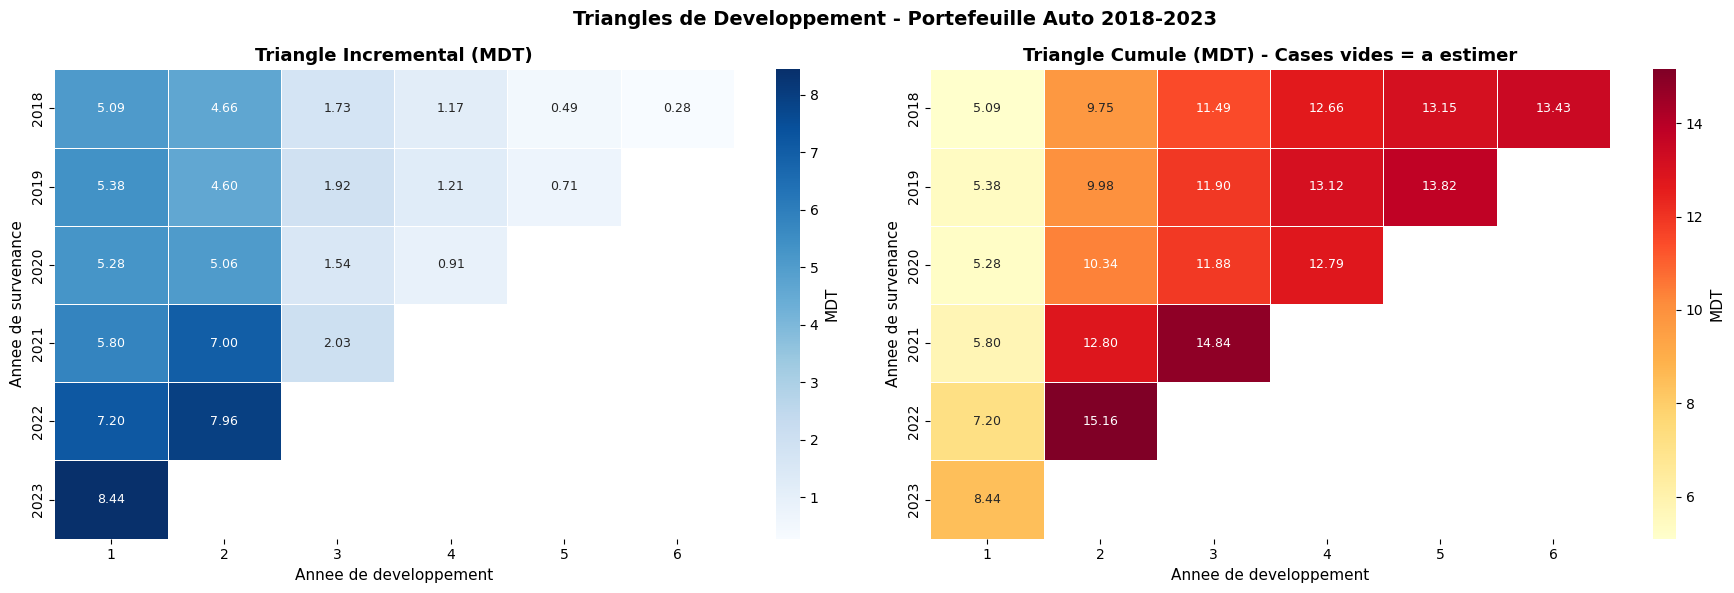

In [4]:
# Heatmap des triangles
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

mask_inc = tri_inc == 0
sns.heatmap(tri_inc / 1e6, annot=True, fmt='.2f', cmap='Blues',
            ax=axes[0], linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'label': 'MDT'}, mask=mask_inc)
axes[0].set_title('Triangle Incremental (MDT)', fontweight='bold')
axes[0].set_xlabel('Annee de developpement')
axes[0].set_ylabel('Annee de survenance')

mask_cumul = tri_cumul.isnull()
sns.heatmap(tri_cumul.fillna(0) / 1e6, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'label': 'MDT'}, mask=mask_cumul)
axes[1].set_title('Triangle Cumule (MDT) - Cases vides = a estimer', fontweight='bold')
axes[1].set_xlabel('Annee de developpement')
axes[1].set_ylabel('Annee de survenance')

plt.suptitle('Triangles de Developpement - Portefeuille Auto 2018-2023',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Methode Chain-Ladder

### Reference : Mack (1993), Taylor (2000)

**Etape 1 - Facteurs de developpement** (moyenne volume-ponderee) :

$$\hat{f}_j = \frac{\sum_{i: j_i > j} C_{i,j+1}}{\sum_{i: j_i > j} C_{i,j}}$$

**Etape 2 - Charge ultime** :

$$\hat{C}_{i,n} = C_{i,j_i} \times \prod_{j=j_i}^{n-1} \hat{f}_j$$

**Etape 3 - Reserve IBNR** :

$$\hat{R}_i^{CL} = \hat{C}_{i,n} - C_{i,j_i}$$


Facteurs de developpement Chain-Ladder (volume-weighted) :
-------------------------------------------------------
  f(1 -> 2) = 2.0186  | proportion supplementaire: +101.9%
  f(2 -> 3) = 1.1686  | proportion supplementaire: +16.9%
  f(3 -> 4) = 1.0935  | proportion supplementaire: +9.4%
  f(4 -> 5) = 1.0464  | proportion supplementaire: +4.6%
  f(5 -> 6) = 1.0215  | proportion supplementaire: +2.1%


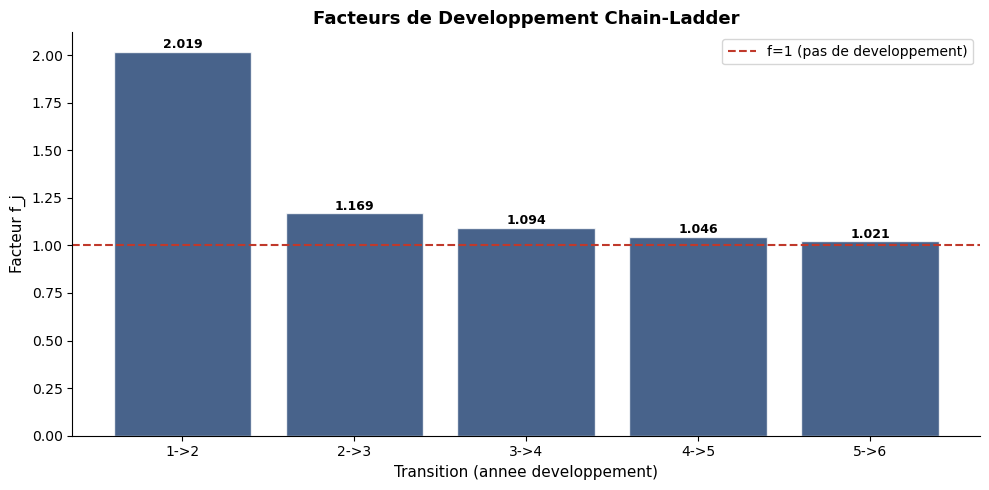

In [5]:
# ETAPE 1 : Facteurs de developpement
facteurs_cl = {}
for j in range(len(devs) - 1):
    dev_j  = devs[j]
    dev_j1 = devs[j + 1]
    col_j  = tri_cumul[dev_j].dropna()
    col_j1 = tri_cumul[dev_j1].dropna()
    idx    = col_j.index.intersection(col_j1.index)
    if len(idx) > 0 and col_j[idx].sum() > 0:
        facteurs_cl[(dev_j, dev_j1)] = col_j1[idx].sum() / col_j[idx].sum()

print("Facteurs de developpement Chain-Ladder (volume-weighted) :")
print("-" * 55)
for (dj, dj1), f in facteurs_cl.items():
    print(f"  f({dj} -> {dj1}) = {f:.4f}  | proportion supplementaire: +{(f-1)*100:.1f}%")

# Visualisation facteurs
fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"{dj}->{dj1}" for (dj, dj1) in facteurs_cl.keys()]
vals   = list(facteurs_cl.values())
bars   = ax.bar(labels, vals, color=C1, alpha=0.8, edgecolor='white')
ax.axhline(1.0, color=C3, linestyle='--', linewidth=1.5, label='f=1 (pas de developpement)')
ax.set_title('Facteurs de Developpement Chain-Ladder', fontweight='bold')
ax.set_xlabel('Transition (annee developpement)')
ax.set_ylabel('Facteur f_j')
ax.legend()
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# ETAPE 2 : Projection du triangle
facteurs_list = list(facteurs_cl.values())
tri_cl = tri_cumul.copy()

for i, annee_surv in enumerate(ANNEES):
    for k, dev in enumerate(devs):
        if pd.isna(tri_cl.loc[annee_surv, dev]):
            if k > 0 and not pd.isna(tri_cl.loc[annee_surv, devs[k-1]]):
                tri_cl.loc[annee_surv, dev] = tri_cl.loc[annee_surv, devs[k-1]] * facteurs_list[k-1]

print("Triangle projete par Chain-Ladder (DT) :")
display(tri_cl.round(0).astype(int))

Triangle projete par Chain-Ladder (DT) :


Developpement,1,2,3,4,5,6
Survenance,,,,,,
2018,5094626,9753665,11488138,12659833,13150816,13433394
2019,5380211,9981574,11902781,13115566,13821215,14118198
2020,5275931,10338181,11878175,12792773,13386683,13674329
2021,5802171,12802341,14835989,16223750,16976944,17341736
2022,7197777,15160398,17716607,19373822,20273259,20708880
2023,8440882,17038753,19911674,21774216,22785092,23274686


In [7]:
# ETAPE 3 : Reserves IBNR
resultats_cl = {}
for i, annee_surv in enumerate(ANNEES):
    dev_actuel    = n - i
    charge_obs    = tri_cumul.loc[annee_surv, dev_actuel]
    charge_ultime = tri_cl.loc[annee_surv, devs[-1]]
    ibnr          = charge_ultime - charge_obs
    sap           = sap_par_annee[annee_surv]

    resultats_cl[annee_surv] = {
        'Charge observee (DT)':    charge_obs,
        'Charge ultime CL (DT)':   charge_ultime,
        'IBNR Chain-Ladder (DT)':  ibnr,
        'SAP 2023 Cie (DT)':       sap,
        'Ecart IBNR vs SAP (%)':   (ibnr - sap) / sap * 100 if sap > 0 else 0
    }

df_cl = pd.DataFrame(resultats_cl).T
df_cl.index.name = 'Annee survenance'
df_cl.loc['TOTAL'] = df_cl.sum(numeric_only=True)
ecart_total = (df_cl.loc['TOTAL','IBNR Chain-Ladder (DT)'] - df_cl.loc['TOTAL','SAP 2023 Cie (DT)'])               / df_cl.loc['TOTAL','SAP 2023 Cie (DT)'] * 100
df_cl.loc['TOTAL', 'Ecart IBNR vs SAP (%)'] = ecart_total

print("Resultats Chain-Ladder :")
display(df_cl.round(0))

ibnr_total_cl = df_cl.loc['TOTAL', 'IBNR Chain-Ladder (DT)']
sap_total_cie = df_cl.loc['TOTAL', 'SAP 2023 Cie (DT)']
print(f"\nReserve totale Chain-Ladder : {ibnr_total_cl:>12,.0f} DT")
print(f"SAP 2023 compagnie          : {sap_total_cie:>12,.0f} DT")
print(f"Ecart                       : {ecart_total:>11.1f} %")

Resultats Chain-Ladder :


,Charge observee (DT),Charge ultime CL (DT),IBNR Chain-Ladder (DT),SAP 2023 Cie (DT),Ecart IBNR vs SAP (%)
Annee survenance,,,,,
2018,13433394.0,13433394.0,0.0,1353156.0,-100.0
2019,13821215.0,14118198.0,296983.0,1760747.0,-83.0
2020,12792773.0,13674329.0,881555.0,2993314.0,-71.0
2021,14835989.0,17341736.0,2505747.0,6309889.0,-60.0
2022,15160398.0,20708880.0,5548482.0,9502566.0,-42.0
2023,8440882.0,23274686.0,14833804.0,16796885.0,-12.0
TOTAL,78484651.0,102551223.0,24066572.0,38716558.0,-38.0



Reserve totale Chain-Ladder :   24,066,572 DT
SAP 2023 compagnie          :   38,716,558 DT
Ecart                       :       -37.8 %


---
## 4. Methode Bornhuetter-Ferguson (BF)

### Reference : Bornhuetter & Ferguson (1972), Mack (2008)

La methode BF est plus robuste pour les **annees recentes** (2022-2023) ou peu de donnees sont disponibles.

**Proportion deja reglee** :

$$q_i = \frac{1}{\prod_{j \geq j_i} \hat{f}_j}$$

**Reserve BF** :

$$\hat{R}_i^{BF} = (1 - q_i) \times \hat{\mu}_i^{(0)} \quad \text{avec} \quad \hat{\mu}_i^{(0)} = P_i \times \hat{\ell}$$

ou $P_i$ est la prime acquise et $\hat{\ell}$ le taux de sinistralite historique moyen.


In [8]:
# Proportions deja reglees q_i
proportions = {}
for i, annee_surv in enumerate(ANNEES):
    dev_actuel     = n - i
    facteurs_futurs = facteurs_list[dev_actuel - 1:]
    if facteurs_futurs:
        produit = 1.0
        for f in facteurs_futurs:
            produit *= f
        q_i = 1.0 / produit
    else:
        q_i = 1.0
    proportions[annee_surv] = q_i

print("Proportions deja reglees q_i :")
for annee_surv, q in proportions.items():
    print(f"  {annee_surv} : q = {q:.4f} ({q*100:.1f}% regle) | reste : {(1-q)*100:.1f}%")

Proportions deja reglees q_i :
  2018 : q = 1.0000 (100.0% regle) | reste : 0.0%
  2019 : q = 0.9790 (97.9% regle) | reste : 2.1%
  2020 : q = 0.9355 (93.6% regle) | reste : 6.4%
  2021 : q = 0.8555 (85.6% regle) | reste : 14.4%
  2022 : q = 0.7321 (73.2% regle) | reste : 26.8%
  2023 : q = 0.3627 (36.3% regle) | reste : 63.7%


In [9]:
# Taux de sinistralite a priori (annees matures 2018-2020)
annees_matures = [2018, 2019, 2020]
sinistralites  = []

for annee_surv in annees_matures:
    q   = proportions[annee_surv]
    dev = n - (annee_surv - 2018)
    charge_obs    = tri_cumul.loc[annee_surv, dev]
    charge_ultime = charge_obs / q if q > 0 else charge_obs
    prime         = primes.get(annee_surv, 0)
    if prime > 0:
        taux = charge_ultime / prime
        sinistralites.append(taux)
        print(f"  {annee_surv} : taux = {taux:.4f} ({taux*100:.2f}%)")

taux_apriori = np.mean(sinistralites)
print(f"\nTaux de sinistralite a priori (BF) : {taux_apriori:.4f} ({taux_apriori*100:.2f}%)")

  2018 : taux = 1.2077 (120.77%)
  2019 : taux = 1.2235 (122.35%)
  2020 : taux = 1.0663 (106.63%)

Taux de sinistralite a priori (BF) : 1.1658 (116.58%)


In [10]:
# Calcul reserves BF
resultats_bf = {}
for i, annee_surv in enumerate(ANNEES):
    q_i     = proportions[annee_surv]
    prime_i = primes.get(annee_surv, 0)
    mu_0    = prime_i * taux_apriori
    ibnr_bf = (1 - q_i) * mu_0
    dev     = n - i
    charge_obs = tri_cumul.loc[annee_surv, dev]

    resultats_bf[annee_surv] = {
        'q_i (% regle)':         round(q_i * 100, 1),
        'Prime acquise (DT)':    prime_i,
        'Ultime a priori (DT)':  mu_0,
        'Charge observee (DT)':  charge_obs,
        'IBNR BF (DT)':          ibnr_bf,
        'SAP 2023 Cie (DT)':     sap_par_annee[annee_surv]
    }

df_bf = pd.DataFrame(resultats_bf).T
df_bf.index.name = 'Annee survenance'
df_bf.loc['TOTAL'] = df_bf.sum(numeric_only=True)
df_bf.loc['TOTAL', 'q_i (% regle)'] = np.nan

print("Resultats Bornhuetter-Ferguson :")
display(df_bf.round(0))

ibnr_total_bf = df_bf.loc['TOTAL', 'IBNR BF (DT)']
print(f"\nReserve totale BF : {ibnr_total_bf:>12,.0f} DT")

Resultats Bornhuetter-Ferguson :


,q_i (% regle),Prime acquise (DT),Ultime a priori (DT),Charge observee (DT),IBNR BF (DT),SAP 2023 Cie (DT)
Annee survenance,,,,,,
2018,100.0,11123391.0,12967770.0,13433394.0,0.0,1353156.0
2019,98.0,11539431.0,13452794.0,13821215.0,282986.0,1760747.0
2020,94.0,12824243.0,14950641.0,12792773.0,963837.0,2993314.0
2021,86.0,15346393.0,17890991.0,14835989.0,2585110.0,6309889.0
2022,73.0,17674303.0,20604894.0,15160398.0,5520622.0,9502566.0
2023,36.0,19475874.0,22705185.0,8440882.0,14470840.0,16796885.0
TOTAL,NaN,87983636.0,102572276.0,78484651.0,23823395.0,38716558.0



Reserve totale BF :   23,823,395 DT


---
## 5. Methode Cape Cod

### Reference : Stanard (1985), Wuthrich & Merz (2008)

**Taux Cape Cod** (estime sur l'ensemble du portefeuille) :

$$\hat{\rho} = \frac{\sum_i C_{i,j_i}}{\sum_i P_i \cdot q_i}$$

**Reserve Cape Cod** :

$$\hat{R}_i^{CC} = (1 - q_i) \cdot \hat{\rho} \cdot P_i$$


In [11]:
# Taux Cape Cod
numerateur   = sum(tri_cumul.loc[a, n - (a - 2018)] for i, a in enumerate(ANNEES))
denominateur = sum(primes.get(a, 0) * proportions[a] for a in ANNEES)
rho_cc       = numerateur / denominateur if denominateur > 0 else 0

print(f"Taux de sinistralite Cape Cod : rho = {rho_cc:.4f} ({rho_cc*100:.2f}%)")
print(f"  Numerateur   (charges obs) : {numerateur:>12,.0f} DT")
print(f"  Denominateur (primes pond) : {denominateur:>12,.0f} DT")
print(f"Taux a priori BF             : {taux_apriori:.4f} ({taux_apriori*100:.2f}%)")
print(f"Ecart BF vs CC               : {(rho_cc - taux_apriori)/taux_apriori*100:.2f}%")

Taux de sinistralite Cape Cod : rho = 1.1619 (116.19%)
  Numerateur   (charges obs) :   78,484,651 DT
  Denominateur (primes pond) :   67,548,593 DT
Taux a priori BF             : 1.1658 (116.58%)
Ecart BF vs CC               : -0.34%


In [12]:
# Reserves Cape Cod
resultats_cc = {}
for i, annee_surv in enumerate(ANNEES):
    q_i     = proportions[annee_surv]
    prime_i = primes.get(annee_surv, 0)
    ibnr_cc = (1 - q_i) * rho_cc * prime_i
    dev     = n - i
    charge_obs = tri_cumul.loc[annee_surv, dev]

    resultats_cc[annee_surv] = {
        'q_i (% regle)':    round(q_i * 100, 1),
        'Prime (DT)':       prime_i,
        'IBNR CC (DT)':     ibnr_cc,
        'Charge obs (DT)':  charge_obs,
        'SAP 2023 (DT)':    sap_par_annee[annee_surv]
    }

df_cc = pd.DataFrame(resultats_cc).T
df_cc.index.name = 'Annee survenance'
df_cc.loc['TOTAL'] = df_cc.sum(numeric_only=True)
df_cc.loc['TOTAL', 'q_i (% regle)'] = np.nan

print("Resultats Cape Cod :")
display(df_cc.round(0))

ibnr_total_cc = df_cc.loc['TOTAL', 'IBNR CC (DT)']
print(f"\nReserve totale Cape Cod : {ibnr_total_cc:>12,.0f} DT")

Resultats Cape Cod :


,q_i (% regle),Prime (DT),IBNR CC (DT),Charge obs (DT),SAP 2023 (DT)
Annee survenance,,,,,
2018,100.0,11123391.0,0.0,13433394.0,1353156.0
2019,98.0,11539431.0,282037.0,13821215.0,1760747.0
2020,94.0,12824243.0,960603.0,12792773.0,2993314.0
2021,86.0,15346393.0,2576436.0,14835989.0,6309889.0
2022,73.0,17674303.0,5502098.0,15160398.0,9502566.0
2023,36.0,19475874.0,14422285.0,8440882.0,16796885.0
TOTAL,NaN,87983636.0,23743459.0,78484651.0,38716558.0



Reserve totale Cape Cod :   23,743,459 DT


---
## 6. Comparaison des Trois Methodes

Comparaison selon les criteres de Mack (1993) et Wuthrich & Merz (2008) :
- Ecarts absolus et relatifs entre methodes par annee de survenance
- Stabilite sur annees recentes vs matures
- Coherence avec les SAP constituees par la compagnie


In [13]:
# Tableau comparatif
comp = pd.DataFrame(index=ANNEES + ['TOTAL'])
comp['IBNR Chain-Ladder (DT)'] = [resultats_cl[a]['IBNR Chain-Ladder (DT)'] for a in ANNEES] + [ibnr_total_cl]
comp['IBNR BF (DT)']           = [resultats_bf[a]['IBNR BF (DT)'] for a in ANNEES] + [ibnr_total_bf]
comp['IBNR Cape Cod (DT)']     = [resultats_cc[a]['IBNR CC (DT)'] for a in ANNEES] + [ibnr_total_cc]
comp['SAP 2023 Cie (DT)']      = [sap_par_annee[a] for a in ANNEES] + [sum(sap_par_annee.values())]
comp['BF vs CL (%)']           = ((comp['IBNR BF (DT)'] - comp['IBNR Chain-Ladder (DT)'])
                                    / comp['IBNR Chain-Ladder (DT)'] * 100).round(1)
comp['CC vs CL (%)']           = ((comp['IBNR Cape Cod (DT)'] - comp['IBNR Chain-Ladder (DT)'])
                                    / comp['IBNR Chain-Ladder (DT)'] * 100).round(1)
comp.index.name = 'Annee'

print("Comparaison des trois methodes :")
display(comp.round(0))

Comparaison des trois methodes :


,IBNR Chain-Ladder (DT),IBNR BF (DT),IBNR Cape Cod (DT),SAP 2023 Cie (DT),BF vs CL (%),CC vs CL (%)
Annee,,,,,,
2018,0.0,0.0,0.0,1353156.0,NaN,NaN
2019,296983.0,282986.0,282037.0,1760747.0,-5.0,-5.0
2020,881555.0,963837.0,960603.0,2993314.0,9.0,9.0
2021,2505747.0,2585110.0,2576436.0,6309889.0,3.0,3.0
2022,5548482.0,5520622.0,5502098.0,9502566.0,-0.0,-1.0
2023,14833804.0,14470840.0,14422285.0,16796885.0,-2.0,-3.0
TOTAL,24066572.0,23823395.0,23743459.0,38716558.0,-1.0,-1.0


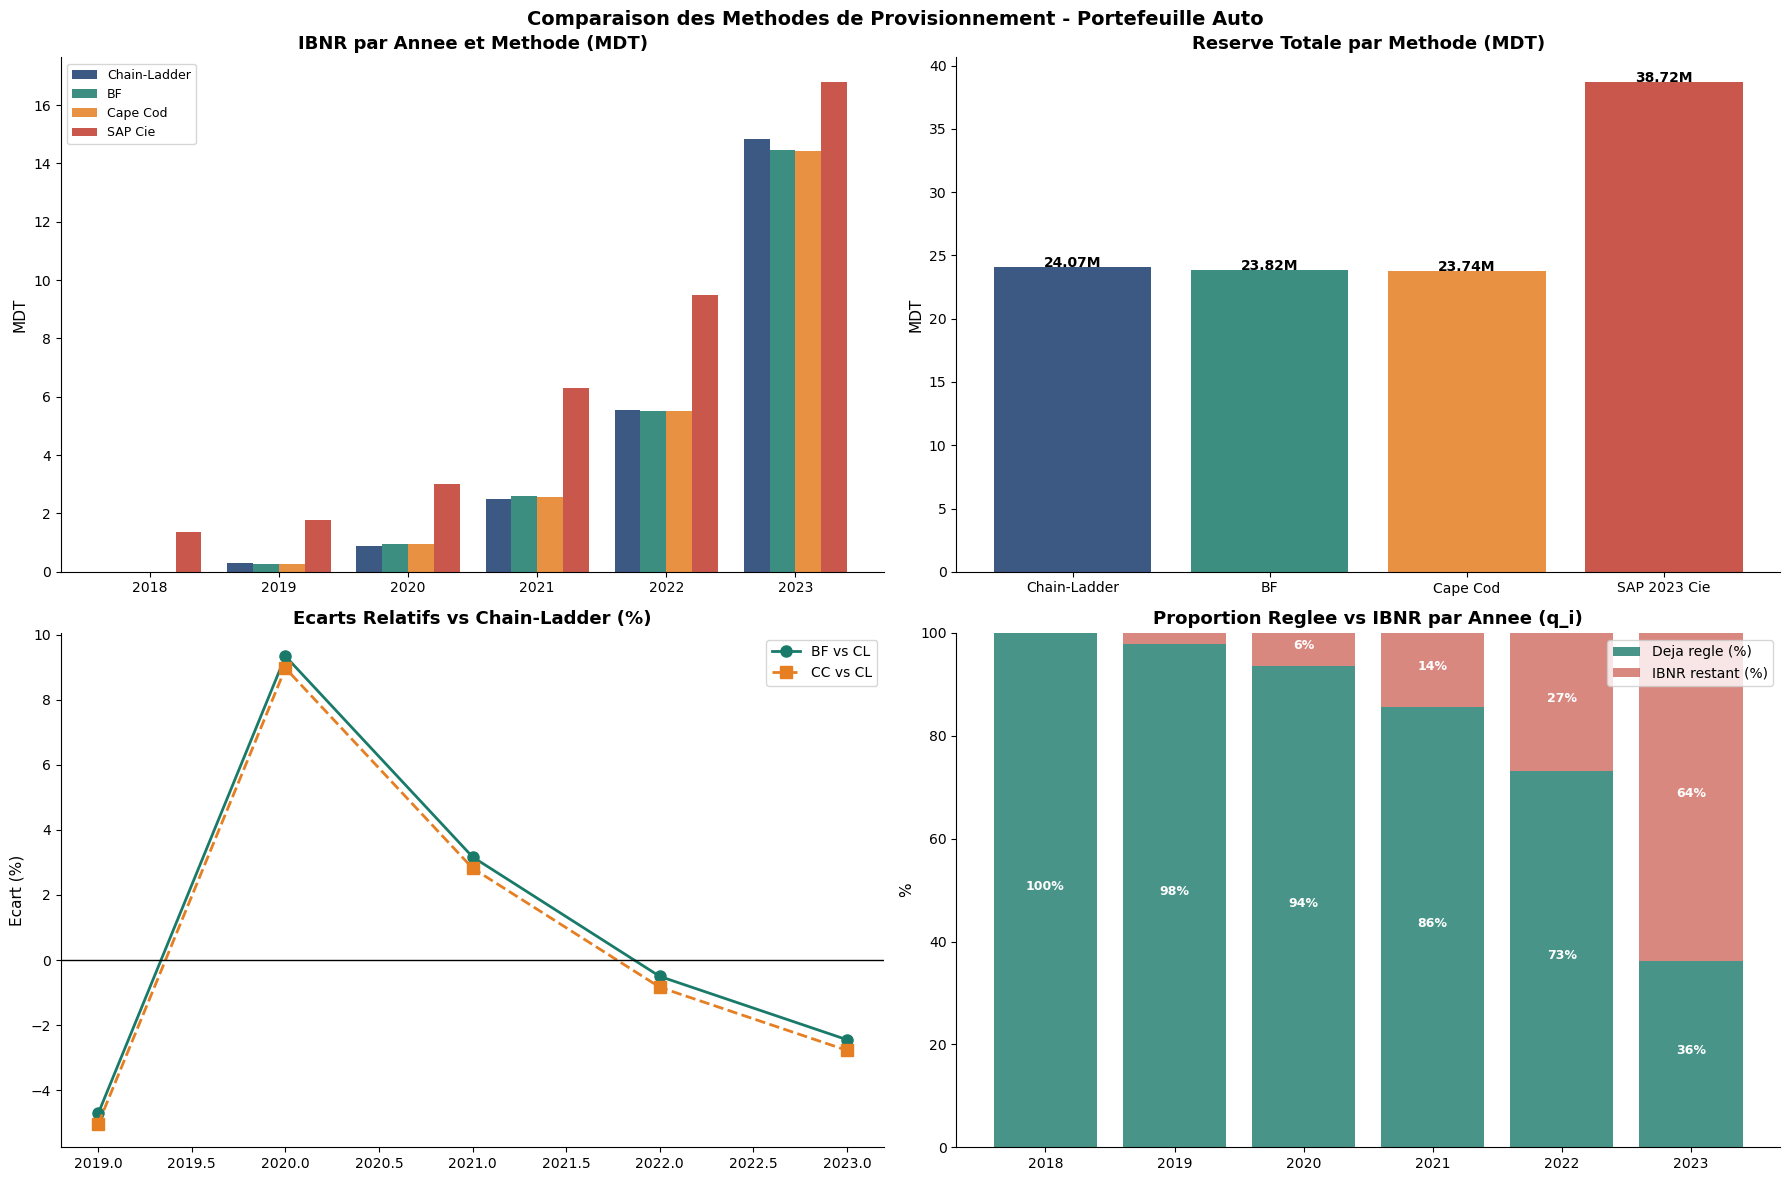

In [14]:
# Visualisations comparatives
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
x = np.arange(len(ANNEES))
w = 0.2

# Barplot IBNR par methode
ax = axes[0][0]
ax.bar(x - w,    [resultats_cl[a]['IBNR Chain-Ladder (DT)'] / 1e6 for a in ANNEES], w, label='Chain-Ladder', color=C1, alpha=0.85)
ax.bar(x,        [resultats_bf[a]['IBNR BF (DT)'] / 1e6 for a in ANNEES],           w, label='BF',           color=C2, alpha=0.85)
ax.bar(x + w,    [resultats_cc[a]['IBNR CC (DT)'] / 1e6 for a in ANNEES],            w, label='Cape Cod',    color=C4, alpha=0.85)
ax.bar(x + 2*w,  [sap_par_annee[a] / 1e6 for a in ANNEES],                           w, label='SAP Cie',     color=C3, alpha=0.85)
ax.set_xticks(x + w/2)
ax.set_xticklabels(ANNEES)
ax.set_title('IBNR par Annee et Methode (MDT)', fontweight='bold')
ax.set_ylabel('MDT')
ax.legend(fontsize=9)

# Reserves totales
ax = axes[0][1]
labels_tot = ['Chain-Ladder', 'BF', 'Cape Cod', 'SAP 2023 Cie']
vals_tot   = [ibnr_total_cl/1e6, ibnr_total_bf/1e6, ibnr_total_cc/1e6, sum(sap_par_annee.values())/1e6]
colors_tot = [C1, C2, C4, C3]
bars = ax.bar(labels_tot, vals_tot, color=colors_tot, alpha=0.85)
ax.set_title('Reserve Totale par Methode (MDT)', fontweight='bold')
ax.set_ylabel('MDT')
for bar, val in zip(bars, vals_tot):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.2f}M', ha='center', fontweight='bold')

# Ecarts relatifs
ax = axes[1][0]
ecarts_bf = [(resultats_bf[a]['IBNR BF (DT)'] - resultats_cl[a]['IBNR Chain-Ladder (DT)'])
             / resultats_cl[a]['IBNR Chain-Ladder (DT)'] * 100 for a in ANNEES]
ecarts_cc = [(resultats_cc[a]['IBNR CC (DT)'] - resultats_cl[a]['IBNR Chain-Ladder (DT)'])
             / resultats_cl[a]['IBNR Chain-Ladder (DT)'] * 100 for a in ANNEES]
ax.plot(ANNEES, ecarts_bf, 'o-', color=C2, linewidth=2, markersize=8, label='BF vs CL')
ax.plot(ANNEES, ecarts_cc, 's--', color=C4, linewidth=2, markersize=8, label='CC vs CL')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Ecarts Relatifs vs Chain-Ladder (%)', fontweight='bold')
ax.set_ylabel('Ecart (%)')
ax.legend()

# Proportions reglees
ax = axes[1][1]
q_vals = [proportions[a] * 100 for a in ANNEES]
reste  = [100 - q for q in q_vals]
ax.bar(ANNEES, q_vals, color=C2, alpha=0.8, label='Deja regle (%)')
ax.bar(ANNEES, reste,  bottom=q_vals, color=C3, alpha=0.6, label='IBNR restant (%)')
ax.set_title('Proportion Reglee vs IBNR par Annee (q_i)', fontweight='bold')
ax.set_ylabel('%')
ax.legend()
for i, (q, r) in enumerate(zip(q_vals, reste)):
    if q > 5:
        ax.text(ANNEES[i], q/2, f'{q:.0f}%', ha='center', color='white', fontweight='bold', fontsize=9)
    if r > 5:
        ax.text(ANNEES[i], q + r/2, f'{r:.0f}%', ha='center', color='white', fontweight='bold', fontsize=9)

plt.suptitle('Comparaison des Methodes de Provisionnement - Portefeuille Auto', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Recommandation par annee
print("Recommandation par annee de survenance :")
print("-" * 68)
print(f"{'Annee':<8} {'Maturite':<12} {'Methode recommandee':<25} {'Justification'}")
print("-" * 68)
for i, annee_surv in enumerate(ANNEES):
    maturite = n - i
    q = proportions[annee_surv] * 100
    if maturite >= 4:
        methode = "Chain-Ladder"
        justif  = f"Donnees matures ({q:.0f}% regle)"
    elif maturite >= 2:
        methode = "Bornhuetter-Ferguson"
        justif  = f"Maturite intermediaire ({q:.0f}% regle)"
    else:
        methode = "BF ou Cape Cod"
        justif  = f"Annee jeune ({q:.0f}% regle) - CL instable"
    print(f"  {annee_surv:<6} {maturite} ans{'':>7} {methode:<25} {justif}")
print()
print("Conclusion : CL pour 2018-2020 | BF pour 2021-2022 | BF/CC pour 2023")

Recommandation par annee de survenance :
--------------------------------------------------------------------
Annee    Maturite     Methode recommandee       Justification
--------------------------------------------------------------------
  2018   6 ans        Chain-Ladder              Donnees matures (100% regle)
  2019   5 ans        Chain-Ladder              Donnees matures (98% regle)
  2020   4 ans        Chain-Ladder              Donnees matures (94% regle)
  2021   3 ans        Bornhuetter-Ferguson      Maturite intermediaire (86% regle)
  2022   2 ans        Bornhuetter-Ferguson      Maturite intermediaire (73% regle)
  2023   1 ans        BF ou Cape Cod            Annee jeune (36% regle) - CL instable

Conclusion : CL pour 2018-2020 | BF pour 2021-2022 | BF/CC pour 2023


---
## 7. Analyse de Sensibilite et Stress Tests

### Reference : England & Verrall (2002), Wuthrich & Merz (2008)

**Scenarios testes :**
1. Cadence de reglement ralentie (+10%, +20%, +30%)
2. Inflation des couts de reparation (+5%, +10%, +15%/an)
3. Scenarios combines (adverse, favorable)
4. Tornado chart - variables les plus impactantes


In [16]:
# Stress Test 1 : Retard de reglement
reserve_base = ibnr_total_cl
retards = [0.0, 0.10, 0.20, 0.30]
reserves_retard = {}

print("STRESS TEST 1 - Retard de reglement")
print("=" * 55)
for retard in retards:
    facteurs_stress = [f * (1 + retard) for f in facteurs_list]
    tri_stress = tri_cumul.copy()
    for i, annee_surv in enumerate(ANNEES):
        for k, dev in enumerate(devs):
            if pd.isna(tri_stress.loc[annee_surv, dev]) and k > 0:
                prev = tri_stress.loc[annee_surv, devs[k-1]]
                if not pd.isna(prev):
                    tri_stress.loc[annee_surv, dev] = prev * facteurs_stress[k-1]

    reserve_stress = sum(
        tri_stress.loc[a, devs[-1]] - tri_cumul.loc[a, n - (a-2018)]
        for a in ANNEES
    )
    reserves_retard[retard] = reserve_stress
    impact = (reserve_stress - reserve_base) / reserve_base * 100
    print(f"  Retard +{retard*100:.0f}%  : {reserve_stress:>12,.0f} DT | impact : {impact:>+7.1f}%")

STRESS TEST 1 - Retard de reglement
  Retard +0%  :   24,066,572 DT | impact :    +0.0%
  Retard +10%  :   57,910,535 DT | impact :  +140.6%
  Retard +20%  :  102,404,934 DT | impact :  +325.5%
  Retard +30%  :  160,075,722 DT | impact :  +565.1%


In [17]:
# Stress Test 2 : Inflation
inflations = [0.0, 0.05, 0.10, 0.15]
reserves_inflation = {}

print("STRESS TEST 2 - Inflation des sinistres")
print("=" * 55)
for infl in inflations:
    reserve_inf = 0
    for i, annee_surv in enumerate(ANNEES):
        ibnr_base        = resultats_cl[annee_surv]['IBNR Chain-Ladder (DT)']
        annees_restantes = n - (n - i)
        facteur_infl     = (1 + infl) ** max(annees_restantes, 1)
        reserve_inf     += ibnr_base * facteur_infl
    reserves_inflation[infl] = reserve_inf
    impact = (reserve_inf - reserve_base) / reserve_base * 100
    print(f"  Inflation +{infl*100:.0f}%/an : {reserve_inf:>12,.0f} DT | impact : {impact:>+7.1f}%")

STRESS TEST 2 - Inflation des sinistres
  Inflation +0%/an :   24,066,572 DT | impact :    +0.0%
  Inflation +5%/an :   29,860,788 DT | impact :   +24.1%
  Inflation +10%/an :   36,742,035 DT | impact :   +52.7%
  Inflation +15%/an :   44,858,724 DT | impact :   +86.4%


SCENARIOS COMBINES
  Favorable            :   20,456,586 DT | vs Base :   -15.0%
  Base (CL)            :   24,066,572 DT | vs Base :    +0.0%
  Modere               :   27,676,557 DT | vs Base :   +15.0%
  Adverse              :  112,645,427 DT | vs Base :  +368.1%
  Tres adverse         :  184,087,080 DT | vs Base :  +664.9%


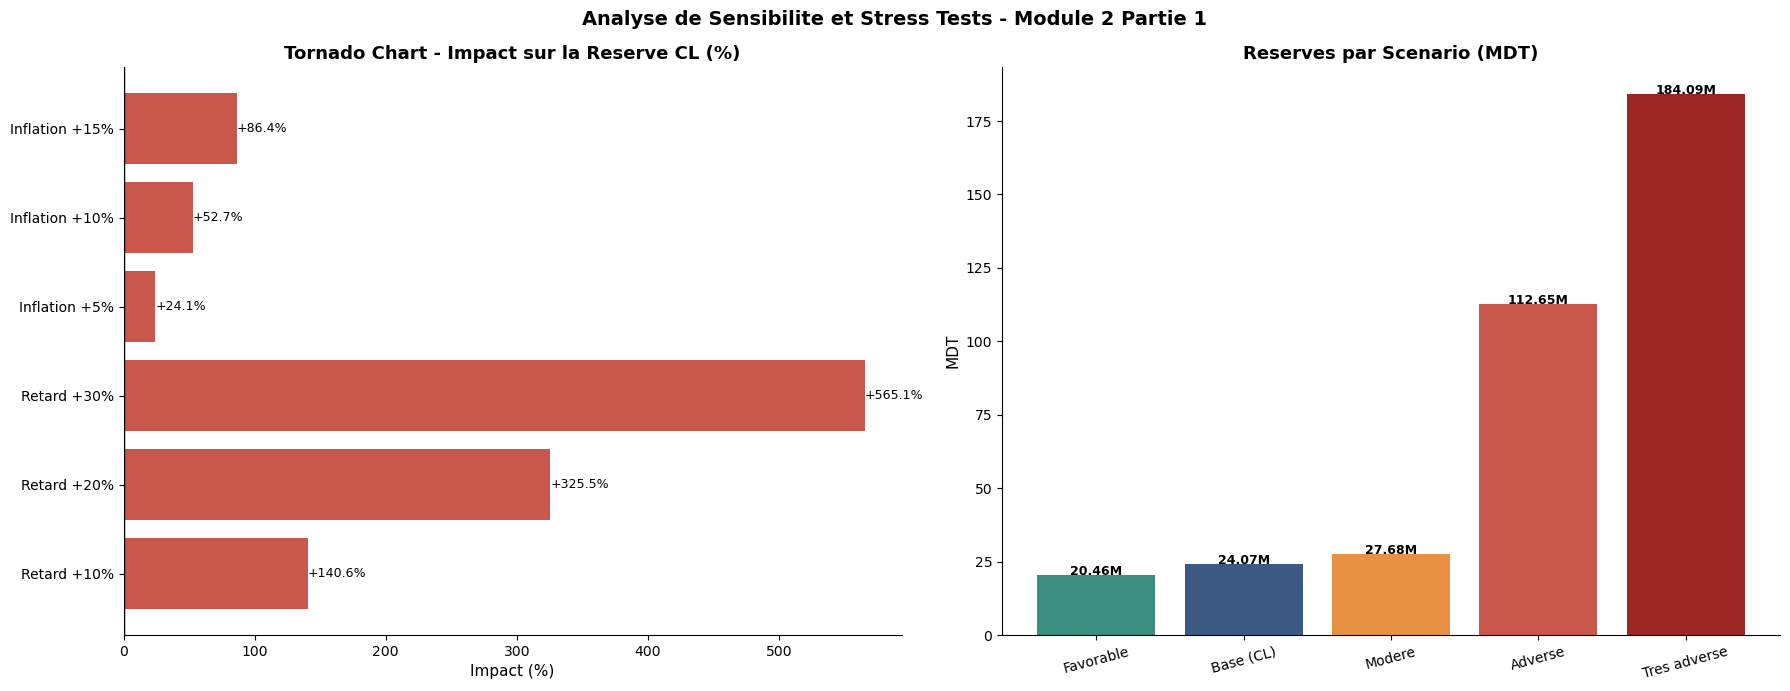

In [18]:
# Scenarios combines
reserve_favorable   = reserve_base * 0.85
reserve_modere      = reserve_base * 1.15
reserve_adverse     = reserves_retard[0.20] * 1.10
reserve_tres_adverse = reserves_retard[0.30] * 1.15

scenarios = {
    'Favorable':     reserve_favorable,
    'Base (CL)':     reserve_base,
    'Modere':        reserve_modere,
    'Adverse':       reserve_adverse,
    'Tres adverse':  reserve_tres_adverse
}

print("SCENARIOS COMBINES")
print("=" * 55)
for nom, val in scenarios.items():
    impact = (val - reserve_base) / reserve_base * 100
    print(f"  {nom:<20} : {val:>12,.0f} DT | vs Base : {impact:>+7.1f}%")

# Visualisation stress tests
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Tornado chart
labels_t = ['Retard +10%', 'Retard +20%', 'Retard +30%',
            'Inflation +5%', 'Inflation +10%', 'Inflation +15%']
impacts_t = (
    [(reserves_retard[r] - reserve_base) / reserve_base * 100 for r in [0.10, 0.20, 0.30]] +
    [(reserves_inflation[inf] - reserve_base) / reserve_base * 100 for inf in [0.05, 0.10, 0.15]]
)
colors_t = [C3 if v > 0 else C2 for v in impacts_t]
axes[0].barh(labels_t, impacts_t, color=colors_t, alpha=0.85)
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Tornado Chart - Impact sur la Reserve CL (%)', fontweight='bold')
axes[0].set_xlabel('Impact (%)')
for i, val in enumerate(impacts_t):
    axes[0].text(val + 0.1 if val >= 0 else val - 0.1, i,
                f'{val:+.1f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

# Scenarios barplot
noms_sc = list(scenarios.keys())
vals_sc = [v / 1e6 for v in scenarios.values()]
colors_sc = [C2, C1, C4, C3, '#8b0000']
bars = axes[1].bar(noms_sc, vals_sc, color=colors_sc, alpha=0.85)
axes[1].set_title('Reserves par Scenario (MDT)', fontweight='bold')
axes[1].set_ylabel('MDT')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, vals_sc):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.2f}M', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Analyse de Sensibilite et Stress Tests - Module 2 Partie 1',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Synthese et Recommandation

  SYNTHESE MODULE 2 PARTIE 1 - ACTUARIAT CLASSIQUE

  SAP 2023 compagnie       :     38,716,558 DT
  Reserve Chain-Ladder     :     24,066,572 DT
  Reserve BF               :     23,823,395 DT
  Reserve Cape Cod         :     23,743,459 DT
  Reserve centrale (CL+BF) :     23,944,983 DT
  Reserve prudentielle     :    184,087,080 DT

  Ecart reserve centrale vs SAP : -38.2%

  RECOMMANDATION FINALE :
  - 2018-2020 : Chain-Ladder (maturite suffisante)
  - 2021-2022 : Bornhuetter-Ferguson (maturite intermediaire)
  - 2023      : BF ou Cape Cod (CL instable sur 1 an)

  LIVRABLES POUR LES MODULES SUIVANTS :
  -> Module 2 Partie 2 : benchmark avec XGBoost ML Reserving
  -> Module 4          : prevision ratio combine (ARIMA/SARIMA)
  -> Module 5          : dashboard Power BI - KPI reserves


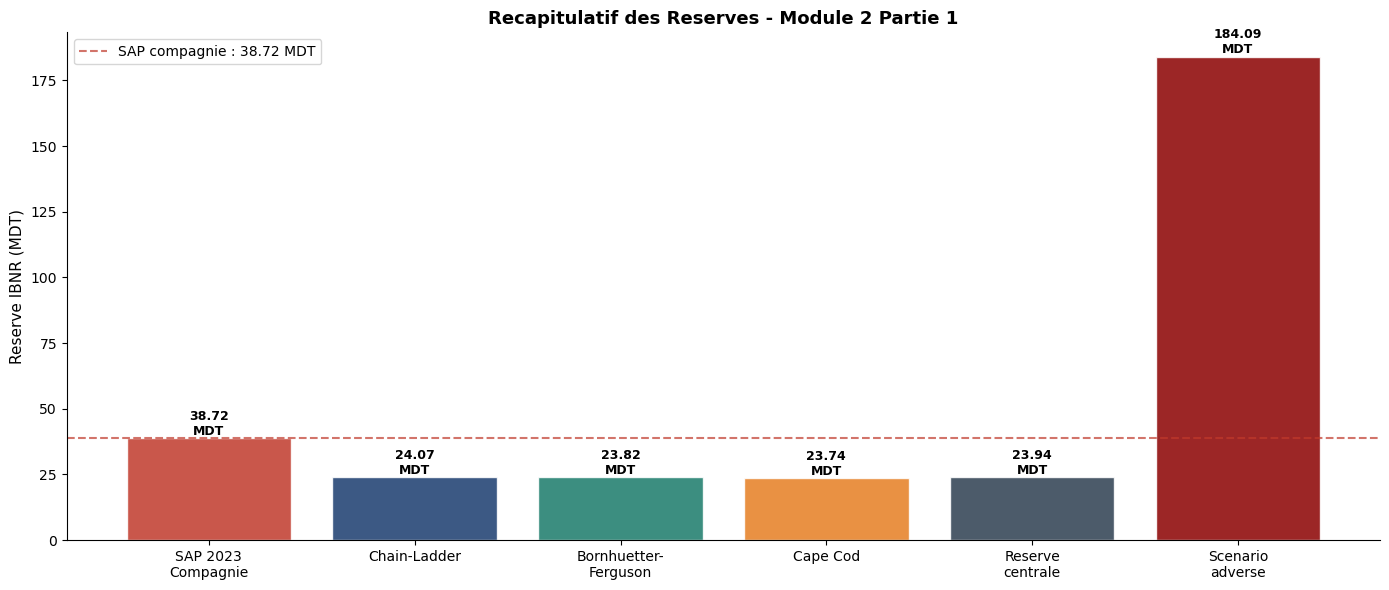


Module 2 Partie 1 termine.
Prochaine etape : Module 2 Partie 2 (Machine Learning Reserving - XGBoost)


In [19]:
# Tableau de synthese
print("=" * 60)
print("  SYNTHESE MODULE 2 PARTIE 1 - ACTUARIAT CLASSIQUE")
print("=" * 60)

sap_total = sum(sap_par_annee.values())
reserve_centrale = (ibnr_total_cl + ibnr_total_bf) / 2

print(f"\n  SAP 2023 compagnie       : {sap_total:>14,.0f} DT")
print(f"  Reserve Chain-Ladder     : {ibnr_total_cl:>14,.0f} DT")
print(f"  Reserve BF               : {ibnr_total_bf:>14,.0f} DT")
print(f"  Reserve Cape Cod         : {ibnr_total_cc:>14,.0f} DT")
print(f"  Reserve centrale (CL+BF) : {reserve_centrale:>14,.0f} DT")
print(f"  Reserve prudentielle     : {reserve_tres_adverse:>14,.0f} DT")

ecart_vs_sap = (reserve_centrale - sap_total) / sap_total * 100
print(f"\n  Ecart reserve centrale vs SAP : {ecart_vs_sap:+.1f}%")
print()
print("  RECOMMANDATION FINALE :")
print("  - 2018-2020 : Chain-Ladder (maturite suffisante)")
print("  - 2021-2022 : Bornhuetter-Ferguson (maturite intermediaire)")
print("  - 2023      : BF ou Cape Cod (CL instable sur 1 an)")
print()
print("  LIVRABLES POUR LES MODULES SUIVANTS :")
print("  -> Module 2 Partie 2 : benchmark avec XGBoost ML Reserving")
print("  -> Module 4          : prevision ratio combine (ARIMA/SARIMA)")
print("  -> Module 5          : dashboard Power BI - KPI reserves")

# Graphique recapitulatif final
fig, ax = plt.subplots(figsize=(14, 6))
methodes = ['SAP 2023\nCompagnie', 'Chain-Ladder', 'Bornhuetter-\nFerguson',
            'Cape Cod', 'Reserve\ncentrale', 'Scenario\nadverse']
valeurs  = [sap_total/1e6, ibnr_total_cl/1e6, ibnr_total_bf/1e6,
            ibnr_total_cc/1e6, reserve_centrale/1e6, reserve_tres_adverse/1e6]
couleurs = [C3, C1, C2, C4, '#2c3e50', '#8b0000']
bars = ax.bar(methodes, valeurs, color=couleurs, alpha=0.85, edgecolor='white')
ax.axhline(sap_total/1e6, color=C3, linestyle='--', linewidth=1.5,
           label=f'SAP compagnie : {sap_total/1e6:.2f} MDT', alpha=0.7)
ax.set_title('Recapitulatif des Reserves - Module 2 Partie 1', fontweight='bold', fontsize=13)
ax.set_ylabel('Reserve IBNR (MDT)')
ax.legend(fontsize=10)
for bar, val in zip(bars, valeurs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.2f}\nMDT', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nModule 2 Partie 1 termine.")
print("Prochaine etape : Module 2 Partie 2 (Machine Learning Reserving - XGBoost)")

In [20]:
# ── Export Module 2 Partie 1 ─────────────────────────────
import os, json
os.makedirs('data', exist_ok=True)

# Tableau comparatif CL vs BF vs Cape Cod vs SAP
comp.to_csv('data/resultats_provisionnement.csv', encoding='utf-8-sig')

# Scénarios stress tests
pd.DataFrame(scenarios.items(), columns=['Scenario','Reserve_DT']).to_csv(
    'data/stress_tests.csv', index=False, encoding='utf-8-sig')

# Triangle de développement (image)
os.makedirs('figures', exist_ok=True)
fig_tri, ax_tri = plt.subplots(figsize=(12, 7))
sns.heatmap(tri_cumul / 1e6, annot=True, fmt='.1f', ax=ax_tri, cmap='YlOrRd')
ax_tri.set_title('Triangle de développement cumulé (MDT)')
plt.tight_layout()
plt.savefig('figures/triangle_development.png', dpi=120, bbox_inches='tight')
plt.close()

print('✅ data/resultats_provisionnement.csv')
print('✅ data/stress_tests.csv')
print('✅ figures/triangle_development.png')

✅ data/resultats_provisionnement.csv
✅ data/stress_tests.csv
✅ figures/triangle_development.png
